**Assignment - Section 5 - Core Data Libraries in Python**

**Titanic Dataset Exploration**

**Libraries used:**
- NumPy
- Pandas
- Matplotlib
- Seaborn

**Goal:**
Understand the Titanic dataset using basic data analysis and visualization.

In [1]:
# installing the required libraries
%pip install numpy pandas matplotlib seaborn -q


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")

**Load the Dataset**

In [3]:
# Make sure titanic.csv is in the same folder
df = pd.read_csv("titanic.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


## Basic Exploration

In [9]:
# Shape, columns, head, info
print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset info:")
print(df.info())


Shape of dataset:
(891, 12)

Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


**Check and Handle Missing Values**

In [10]:
# Check missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Handle missing values (simple approach)
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna("Unknown")

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


## Survival Analysis

## Average Age and Fare

In [8]:
# Average age and fare
print("\nAverage Age:", df["Age"].mean())
print("Average Fare:", df["Fare"].mean())


Average Age: 29.69911764705882
Average Fare: 32.204207968574636


## Visualizations

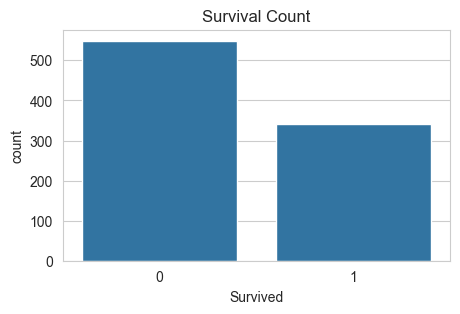

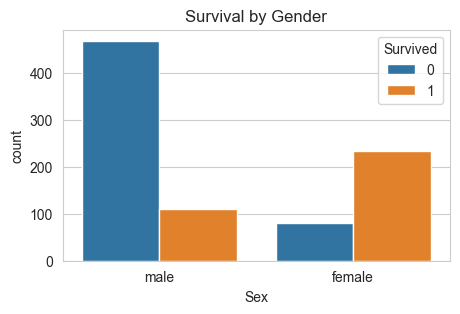

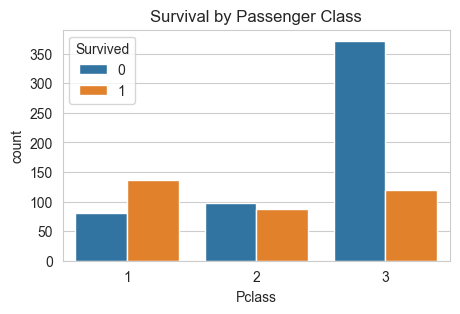

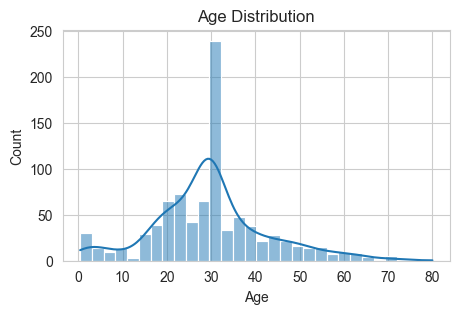

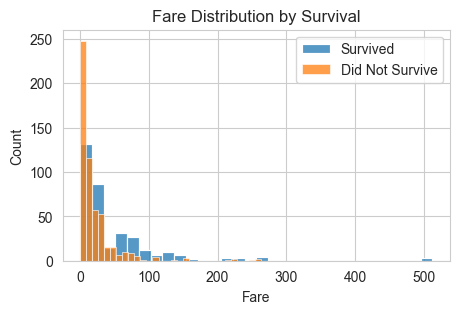

In [15]:
# Survival count plot
plt.figure(figsize=(5,3))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

# Survival by gender
plt.figure(figsize=(5,3))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

# Survival by passenger class
plt.figure(figsize=(5,3))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

# Age distribution
plt.figure(figsize=(5,3))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Fare distribution for survivors vs non-survivors
plt.figure(figsize=(5,3))
sns.histplot(df[df["Survived"] == 1]["Fare"], label="Survived", bins=30)
sns.histplot(df[df["Survived"] == 0]["Fare"], label="Did Not Survive", bins=30)
plt.legend()
plt.title("Fare Distribution by Survival")
plt.show()

## Bonus: Age Groups Analysis


Survival rate by age group:
AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


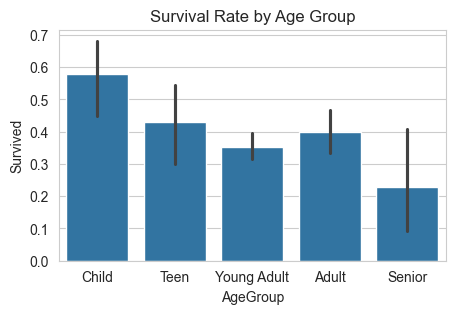

In [16]:
# Age groups analysis
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

print("\nSurvival rate by age group:")
print(df.groupby("AgeGroup")["Survived"].mean())

plt.figure(figsize=(5,3))
sns.barplot(x="AgeGroup", y="Survived", data=df)
plt.title("Survival Rate by Age Group")
plt.show()

---

**Titanic data exploration completed.**